<a href="https://colab.research.google.com/github/Sigurd-RW/lis4693/blob/main/lab4/Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
import requests
import io
import tarfile

url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"

response = requests.get(url)
response.raise_for_status()

file_like = io.BytesIO(response.content)

tar = tarfile.open(fileobj=file_like, mode="r:gz")
tar.extractall()

/tmp/ipykernel_54255/1667380608.py:13: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [3]:
import os
import pandas as pd

texts = []
labels = []

for label in ["pos", "neg"]:
    path = f"aclImdb/train/{label}"

    for file in os.listdir(path):
        with open(os.path.join(path, file), encoding="utf-8") as f:
            texts.append(f.read())
            labels.append(label)

df = pd.DataFrame({
    "text": texts,
    "sentiment": labels
})

print(df.head())

                                                text sentiment
0  STAR RATING: ***** The Works **** Just Misses ...       pos
1  Watch On The Rhine started as a Broadway play ...       pos
2  I gave this film an 10/10 with some reluctance...       pos
3  Shamefully, before I saw this film, I was unfa...       pos
4  Roman Polanski is considered as one of the mos...       pos


In [4]:
features = df['text']
target = df['sentiment']

In [5]:
target_names = {
    'pos': 1,
    'neg': 0
}

In [6]:
target_names = {'pos': 1, 'neg': 0}
target = target.replace(target_names)

/tmp/ipykernel_54255/4101172796.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target = target.replace(target_names)


In [7]:
target = target.replace(target_names)

I chose these just because that's what was there in the dataset.

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')
X_test = X_test.fillna('')

# Preprocessing pipeline
preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 20000 samples.
Testing set has 5000 samples.
Preprocessing training data...
Preprocessing test data...


In [10]:
y_test.unique()

array([1, 0])

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# --- Initialize classifiers ---
nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr", max_iter=1000)  # add max_iter to avoid warnings

# --- Train classifiers ---
print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)

Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr')

In [12]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)

In [13]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))

NB Accuracy: 0.8676
SVM Accuracy: 0.896
LR Accuracy: 0.8924


In [14]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))
print(classification_report(y_test, svm_predictions, target_names=target_names))


              precision    recall  f1-score   support

         pos       0.85      0.90      0.87      2485
         neg       0.89      0.84      0.86      2515

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000

              precision    recall  f1-score   support

         pos       0.89      0.89      0.89      2485
         neg       0.89      0.90      0.89      2515

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000

              precision    recall  f1-score   support

         pos       0.90      0.89      0.89      2485
         neg       0.89      0.90      0.90      2515

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



Model 1 has the lowest results while model 3 has the highest results. But they're all pretty close.

In [15]:
from sklearn.model_selection import GridSearchCV

parameters = {'C': np.logspace(0, 3, 10)}
parameters = {'C': [0.1, 1, 10, 100, 1000]}

print("Grid search for SVM")
svm_best = GridSearchCV(svm_classifier, parameters, cv=10, verbose=1)
svm_best.fit(train_preprocessed, y_train)

Grid search for SVM
Fitting 10 folds for each of 5 candidates, totalling 50 fits


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

GridSearchCV(cv=10, estimator=LinearSVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000]}, verbose=1)

In [16]:
print("Best SVM Parameters")
print(svm_best.best_params_)

Best SVM Parameters
{'C': 1}


In [17]:
best_svm_predictions = svm_best.predict(test_preprocessed)

print("Best SVM Accuracy:", np.mean(best_svm_predictions == y_test))

Best SVM Accuracy: 0.896


In [18]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, svm_predictions, target_names=target_names))

              precision    recall  f1-score   support

         pos       0.90      0.89      0.89      2485
         neg       0.89      0.90      0.90      2515

    accuracy                           0.90      5000
   macro avg       0.90      0.90      0.90      5000
weighted avg       0.90      0.90      0.90      5000



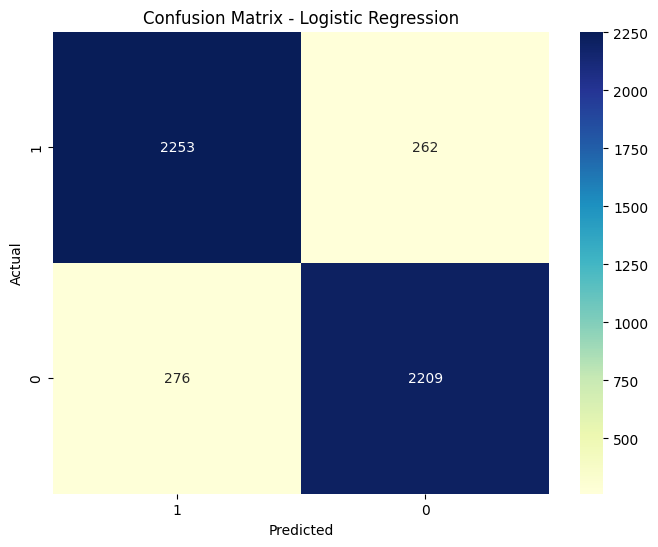

In [19]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

best_pred = lr_classifier.predict(test_preprocessed)

labels = [1, 0]  # 1 = pos, 0 = neg
conf_matrix = confusion_matrix(y_test, best_pred, labels=labels)
conf_matrix_df = pd.DataFrame(conf_matrix, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_df, annot=True, fmt='d', cmap="YlGnBu")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [20]:
import pandas as pd
import requests
import io

url = "https://raw.githubusercontent.com/Sigurd-RW/lis4693/refs/heads/main/lab4/newdata.csv"
response = requests.get(url)
response.raise_for_status() # Raise an exception for HTTP errors
raw_csv_data = response.text # Store the raw CSV string

new_data = pd.read_csv(io.StringIO(raw_csv_data))
print(new_data.head())

                                                text sentiment
0  I absolutely loved this movie! The acting was ...          
1                  The film was boring and too long.          
2        An amazing experience from start to finish.          
3   I didn't enjoy the plot, it was too predictable.          
4              Terrible movie, I walked out halfway.          


In [21]:
text = new_data['text']

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [23]:
vect = TfidfVectorizer(stop_words = 'english').fit(X_train)
dtm = vect.fit_transform(X_train)

In [24]:
from sklearn.ensemble import AdaBoostClassifier
model = AdaBoostClassifier()
classif = model.fit(dtm, y_train)

In [25]:
test_dtm = vect.transform(new_data['text'])

In [26]:
import pandas as pd

# Replace NaN values with an empty string before applying transform
new_data['text'] = new_data['text'].fillna('')
test_dtm = vect.transform(new_data['text'])

In [27]:
test = classif.predict(test_dtm)

In [28]:
df2 = pd.DataFrame(test)
df2.rename(columns={0: 'code_choice'}, inplace=True)

In [29]:
new_data['code_choice'] = df2['code_choice']
combined_df = new_data

In [32]:
display(combined_df.head(100))

,text,sentiment,code_choice
0,I absolutely loved this movie! The acting was ...,,1
1,The film was boring and too long.,,0
2,An amazing experience from start to finish.,,1
3,"I didn't enjoy the plot, it was too predictable.",,0
4,"Terrible movie, I walked out halfway.",,0
...,...,...,...
95,Captivating and beautifully shot.,,1
96,"Disappointing execution, weak story.",,1
97,"Thrilling and engaging, I loved it.",,1
98,"Not memorable, quite boring.",,0


The ones I looked at all seem to be accurate. So it must be a pretty good model.

In [33]:
combined_df.to_csv('predicted_data.csv', index=False)

What went well: I was able to figure it out at least.
What didn't: This was very hard for me to figure out due to the type of dataset I was assigned. I could not easily view it and I needed to use a lot of guess work. I hope I did it right.